# Group into Pathways

This notebook checks which 'gates' the idividual drifters pass to group them into tracks (eg. northern necirculation, southern recirculation, ...)\
The result is saved as .pkl files in a custom dataclass.

## Imports

In [1]:
# General
import numpy as np
import sys

# data handling
import xarray as xr
import pickle

# Plotting
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs

# Other
from shapely.geometry import LineString

# Custom
sys.path.append('/albedo/work/user/quraus001/FESOM_particles/analysis/functions/')
from ocean_helper import classify_water_mass
import helper as hlp
import particles_loading as pload
import plotting_functions as plf
from custom_classes import GateResult, GatesSummary

## Load Data

In [33]:
inpath = "/albedo/work/user/quraus001/FESOM_particles/result/"

filename = "drifter_output_2006-182_lat-76_particles-2640_tracking-730d_2026-05-20.nc" 
LAT = 76

ds, STEPS_PER_DAY, DOY, YEAR, release_date = pload.read_particle_data(inpath + filename)


# Bathymetry Data for plotting
ds_bath = xr.open_dataset("/albedo/work/user/quraus001/bath/ETOPO_2022_v1_60s_N90W180_bed.nc")
# select only reagion of interest
ds_bath = ds_bath.sel(lon=slice(-40, 40), lat=slice(70, 90))


# Show particle dataset
ds

Release date: 2006-07-01 00:00:00
 - Day of year: 182
 - Out steps per day: 12


<xarray.Dataset> Size: 4GB
Dimensions:       (drifter: 2245, depth_levels: 47, time: 8760)
Coordinates:
  * drifter       (drifter) int32 9kB 1 2 3 4 5 6 ... 2241 2242 2243 2244 2245
  * depth_levels  (depth_levels) float64 376B 0.0 10.0 20.0 ... 5.9e+03 6.15e+03
  * time          (time) datetime64[ns] 70kB 2006-07-01 ... 2008-06-30T22:00:00
Data variables: (12/26)
    day           (time) int32 35kB ...
    year          (time) int32 35kB ...
    lon           (drifter, time) float64 157MB ...
    lat           (drifter, time) float64 157MB 76.0 76.0 76.01 ... nan nan nan
    depth         (drifter, time) float64 157MB 10.0 10.02 10.03 ... nan nan nan
    temp          (drifter, time) float64 157MB 6.387 6.436 6.147 ... nan nan
    ...            ...
    sigma0        (drifter, time) float64 157MB 27.4 27.4 27.43 ... nan nan nan
    vort          (drifter, time) float64 157MB 3.829e-06 ... -2.269e-05
    strain        (drifter, time) float64 157MB 1.388e-05 ... 2.414e-05
    okubo_weiss   (drifter, time) float64 157MB 1.78e-10 1.835e-10 ... 6.827e-11
    Ro            (drifter, time) float64 157MB 0.02706 0.03055 ... nan nan
    f             (drifter, time) float64 157MB 0.0001415 0.0001415 ... nan nan
Attributes:
    long_name:              relative vortici
    steps_per_day:          240
    n_out:                  20
    total_experiment_days:  730
    release_start_year:     2006
    release_start_doy:      182
    output_description:     Particle tracking run starting on specified relea...
    direction:              forward tracking
    start_position_file:    drifter_input_2006-182_lat-76_particles-2640.dat
    save_column:            false

## Get Gate Crossings

In [20]:
# Define multi-segment gates
P1 = LineString([(3, 79.1), (14, 79.1)] )                       # north gate
P2 = LineString([(-2, 75), (0.5, 79), (-2, 80.2), (-12, 81)] )  # recirculation gate
P3 = LineString([(14, 79.8), (8, 81.2), (13, 81.5)] )           # Arctic exit gate
P4 = LineString([(-2, 81), (4, 81)] )                           # Yermak exit gate
P5 = LineString([(16.7, 76.6), (20, 73.5)] )                  # South svalbard exit gate

gates = {
    "P1": P1,
    "P2": P2,
    "P3": P3,
    "P4": P4,
    "P5": P5
}

### Functions

In [21]:
def get_clean_crossings(ds, gates, drifter_ids=None):
    """
    Find which drifters cross a set of gates.

    Parameters
    ----------
    ds : xarray.Dataset
        Dataset containing drifter trajectories with variables 'lon', 'lat',
        and a 'drifter' coordinate holding drifter IDs.
    gates : dict
        Dictionary mapping gate names to Shapely LineString objects
        representing the gate lines to check crossings against.
    drifter_ids : array-like, optional
        Subset of drifter IDs to process. If None, all drifters in the
        dataset are processed.

    Returns
    -------
    gate_sets : dict
        Dictionary mapping gate names to sets of drifter IDs that crossed
        that gate. Same keys as the input `gates` dictionary.

    Examples
    --------
    >>> crossings = get_clean_crossings(ds, gates)
    >>> crossings = get_clean_crossings(ds, gates, drifter_ids=[101, 202, 303])
    """
    gate_sets = {name: set() for name in gates.keys()}
    
    # Use provided drifter_ids or default to all drifters
    ids_to_process = drifter_ids if drifter_ids is not None else ds.drifter.values
    
    for d_id in ids_to_process:
        # 1. Extract the data
        lon = ds.lon.sel(drifter=d_id).values
        lat = ds.lat.sel(drifter=d_id).values
        
        # Remove NaNs 
        mask = ~np.isnan(lon) & ~np.isnan(lat)
        clean_lon = lon[mask]
        clean_lat = lat[mask]
        
        # Check if we have enough points to make a line
        if len(clean_lon) < 2:
            continue
        
        # Create trajectory
        trajectory = LineString(np.column_stack((clean_lon, clean_lat)))
        
        # Intersection Check
        for name, gate_line in gates.items():
            if trajectory.intersects(gate_line):
                gate_sets[name].add(d_id)
    
    return gate_sets

def get_final_drifter_states(ds, lon_min=-40, lon_max=40, lat_min=72, lat_max=87, buffer=0.2, drifter_ids=None):
    """
    Classify drifters into three categories based on their final position.

    Parameters
    ----------
    ds : xarray.Dataset
        Dataset containing drifter trajectories with variables 'lon', 'lat',
        and a 'drifter' coordinate holding drifter IDs.
    lon_min : float, optional
        Minimum longitude of the domain boundary. Default is -40.
    lon_max : float, optional
        Maximum longitude of the domain boundary. Default is 40.
    lat_min : float, optional
        Minimum latitude of the domain boundary. Default is 72.
    lat_max : float, optional
        Maximum latitude of the domain boundary. Default is 87.
    buffer : float, optional
        Buffer zone in degrees around the domain boundary to detect exits. Default is 0.2.
    drifter_ids : array-like, optional
        Subset of drifter IDs to process. If None, all drifters in the
        dataset are processed.

    Returns
    -------
    exited_ids : set
        Drifter IDs that stopped near a domain boundary (likely exited the domain).
    beached_ids : set
        Drifter IDs that stopped before the end of the simulation and not near a boundary (likely beached).
    still_active_ids : set
        Drifter IDs that were still active at the final time step.

    Examples
    --------
    >>> exited, beached, active = classify_drifters(ds)
    >>> exited, beached, active = classify_drifters(ds, drifter_ids=[101, 202, 303])
    """
    final_time_step = len(ds.time) - 1
    exited_ids = set()
    beached_ids = set()
    still_active_ids = set()
    still_active_ids_aw = set()

    ids_to_process = drifter_ids if drifter_ids is not None else ds.drifter.values

    for d_id in ids_to_process:
        # Get all positions for this drifter
        lon_vals = ds.lon.sel(drifter=d_id).values
        lat_vals = ds.lat.sel(drifter=d_id).values

        # Find last valid index
        valid_idx = np.where(np.isfinite(lon_vals))[0]
        if len(valid_idx) == 0:
            continue
        last_idx = valid_idx[-1]
        last_lon = lon_vals[last_idx]
        last_lat = lat_vals[last_idx]

        # CATEGORY A: Reached the end of the simulation time
        if last_idx == final_time_step:
            still_active_ids.add(d_id)

            d_last = ds.sel(drifter=d_id).isel(time=-1)
            if classify_water_mass(d_last.temp.values, d_last.salt.values) == "AW":
                still_active_ids_aw.add(int(d_id))

        # CATEGORY B: Stopped before the end
        else:
            at_boundary = (
                last_lon <= lon_min + buffer or
                last_lon >= lon_max - buffer or
                last_lat <= lat_min + buffer or
                last_lat >= lat_max - buffer
            )
            if at_boundary:
                exited_ids.add(d_id)
            else:
                beached_ids.add(d_id)

    return exited_ids, beached_ids, still_active_ids, still_active_ids_aw

In [22]:
def get_crossing_times(ds, gates, drifter_ids=None):
    ids_to_process = drifter_ids if drifter_ids is not None else ds.drifter.values
    crossing_times = {d_id: {name: [] for name in gates} for d_id in ids_to_process}

    for d_id in ids_to_process:
        lon = ds.lon.sel(drifter=d_id).values
        lat = ds.lat.sel(drifter=d_id).values

        for t in range(len(lon) - 1):
            if not all(np.isfinite([lon[t], lat[t], lon[t+1], lat[t+1]])):
                continue
            
            segment = LineString([(lon[t], lat[t]), (lon[t+1], lat[t+1])])
            
            for name, gate_line in gates.items():
                if segment.intersects(gate_line):
                    crossing_times[d_id][name].append(t)

    return crossing_times

def get_sequential_crossings(ds, gates, gate_first, gate_second, drifter_ids=None):
    """
    Find drifters that cross gate_first before gate_second.

    Parameters
    ----------
    ds : xarray.Dataset
        Dataset containing drifter trajectories.
    gates : dict
        Dictionary mapping gate names to Shapely LineString objects.
    gate_first : str
        Name of the gate that should be crossed first.
    gate_second : str
        Name of the gate that should be crossed second.
    drifter_ids : array-like, optional
        Subset of drifter IDs to process. If None, all drifters are processed.

    Returns
    -------
    sequential_crossers : set
        Drifter IDs that crossed gate_first before gate_second.

    Examples
    --------
    >>> p3_then_p2 = get_sequential_crossings(ds, gates, 'P3', 'P2', drifter_ids=s3 & s2)
    """
    crossing_times = get_crossing_times(ds, gates, drifter_ids=drifter_ids)

    sequential_crossers = set()
    for d_id, times in crossing_times.items():
        first_times = times[gate_first]
        second_times = times[gate_second]

        if first_times and second_times:
            if any(t1 < t2 for t1 in first_times for t2 in second_times):
                sequential_crossers.add(d_id)

    return sequential_crossers

### Calls

In [34]:
# Check for AW at start (Because of the NN method to get the drifter locations the true starting value might not be AW anymore)
all_drifter_ids = ds.drifter.values
aw_drifters = []

for d_id in all_drifter_ids:
    # Get initial temp/salt for this specific drifter
    d_initial = ds.sel(drifter=d_id).isel(time=0)
    if classify_water_mass(d_initial.temp.values, d_initial.salt.values) == "AW":
        aw_drifters.append(int(d_id))

aw_set = set(aw_drifters)

exited_ids_aw, beached_ids_aw, still_active_ids_aw, still_active_ids_end_aw = get_final_drifter_states(ds, drifter_ids=aw_set)
s_gates = get_clean_crossings(ds, gates, drifter_ids=aw_set)
s1, s2, s3, s4, s5 = s_gates["P1"], s_gates["P2"], s_gates["P3"], s_gates["P4"], s_gates["P5"]
all_crossers = s2 | s3 | s4 | s5   # Union of all sets     s1 | 


print("Drifter Experiment Short Overview")
print("---------------------------------")
print(f"Total Drifters: {len(ds.drifter)}")
print()
print(f"AW starting Drifters: {len(aw_set)}")
print(f"   of which")
print(f"   Still Active (End AW):   {len(still_active_ids_aw)} ({len(still_active_ids_end_aw)})")
print(f"   Exited Domain:  {len(exited_ids_aw)}")
print(f"   Beached/Stuck:  {len(beached_ids_aw)}")
print("")
print(f"AW gate crossings")

print(f"   any gate (P2-P5):         {len(all_crossers):3d}")
print(f"   died without crossing P2-P5 {len(beached_ids_aw - all_crossers):3d}")
print(f"   still active without crossing (End AW){len(still_active_ids_aw - all_crossers):3d} ({len(still_active_ids_end_aw - all_crossers)})")

Drifter Experiment Short Overview
---------------------------------
Total Drifters: 2245

AW starting Drifters: 2191
   of which
   Still Active (End AW):   717 (269)
   Exited Domain:  755
   Beached/Stuck:  719

AW gate crossings
   any gate (P2-P5):         1774
   died without crossing P2-P5 320
   still active without crossing (End AW) 48 (21)


In [35]:
south    = s2 - s1 - s3 - s4 # Gate P2 but not any other

p1_then_p2 = get_sequential_crossings(ds, gates, gate_first="P1", gate_second="P2", drifter_ids=(s1 & s2))
north    = p1_then_p2 - s3 - s4 # first P1 then P2 and not P3 or P4

p3_then_p2 = get_sequential_crossings(ds, gates, gate_first="P3", gate_second="P2", drifter_ids=(s2 & s3)) # These calls take a bit of time
p4_then_p2 = get_sequential_crossings(ds, gates, gate_first="P4", gate_second="P2", drifter_ids=(s2 & s4))
yermak   = p3_then_p2 | p4_then_p2 # P2 after P3 or P4 

arctic   = (s3 | s4) - yermak # P3 or P4 but no P2 after
svalbard = s5 - s4 - s3 - s2 -s1 # P5 but not any other

### Saving

In [36]:
# --- Build GateResult objects ---

# Raw gate crossings
r_s1 = GateResult(data=s1, name="P1", desc="Fram Strait West")
r_s2 = GateResult(data=s2, name="P2", desc="Fram Strait Recirculated")
r_s3 = GateResult(data=s3, name="P3", desc="Arctic Entrance")
r_s4 = GateResult(data=s4, name="P4", desc="Yermak Plateau East")
r_s5 = GateResult(data=s5, name="P5", desc="South Svalbard")

# Derived track categories
r_north    = GateResult(data=north,    name="north",    desc="North Recirculation (P1→P2, not P3/P4)")
r_south    = GateResult(data=south,    name="south",    desc="South Recirculation (P2 only)")
r_yermak   = GateResult(data=yermak,   name="yermak",   desc="Yermak Return (P2 after P3 or P4)")
r_arctic   = GateResult(data=arctic,   name="arctic",   desc="Arctic Track (P3 or P4, no P2 after)")
r_svalbard = GateResult(data=svalbard, name="svalbard", desc="South Svalbard Track (P5 only)")

# Summary sets
r_all_crossers       = GateResult(data=all_crossers,            name="all_crossers",       desc="Crossed any gate (P2–P5)")
r_beached            = GateResult(data=beached_ids_aw,          name="beached",            desc="Beached or stuck")
r_active             = GateResult(data=still_active_ids_aw,     name="active",             desc="Still active")
r_still_active_end_aw = GateResult(data=still_active_ids_end_aw, name="still_active_end_aw", desc="Still active at end and still AW at the end")

# --- Assemble the GatesSummary ---

summary = GatesSummary(
    name="AW Drifter Experiment",
    desc="Atlantic Water drifters only, classified at t=0",
    num_particles=len(ds.drifter),
    num_aw_particles=len(aw_set),

    # Raw gates
    s1=r_s1, s2=r_s2, s3=r_s3, s4=r_s4, s5=r_s5,

    # Tracks
    north=r_north, south=r_south, yermak=r_yermak,
    arctic=r_arctic, svalbard=r_svalbard,

    # Summary
    all_crossers=r_all_crossers,
    beached=r_beached,
    active=r_active,
    still_active_end_aw=r_still_active_end_aw,
)

# --- Print using the built-in summary method ---
summary.summary()


=== AW Drifter Experiment ===
    Atlantic Water drifters only, classified at t=0
Total particles: 2245
Particles still active at end of tracking: 2191
  north         252 (North Recirculation (P1→P2, not P3/P4))
  south         627 (South Recirculation (P2 only))
  yermak        130 (Yermak Return (P2 after P3 or P4))
  arctic        609 (Arctic Track (P3 or P4, no P2 after))
  svalbard      144 (South Svalbard Track (P5 only))
  all_crossers 1774 (Crossed any gate (P2–P5))
  beached       719 (Beached or stuck)
  active        717 (Still active)
  uncategorized   12
  died without crossing: 320
  still active without crossing (End AW) 48 (21)


In [37]:
outpath = "/albedo/work/user/quraus001/FESOM_particles/result/processed_results/"
name = filename.removesuffix(".nc").removeprefix("drifter_output_")
outfile = f"Gates_{name}.pkl"

# Save the dataclass object
with open(outpath + outfile, "wb") as f:
    pickle.dump(summary, f)

print(f"Successfully saved dataclass to {outpath + outfile}")

Successfully saved dataclass to /albedo/work/user/quraus001/FESOM_particles/result/processed_results/Gates_2006-182_lat-76_particles-2640_tracking-730d_2026-05-20.pkl


## Some Control Plots

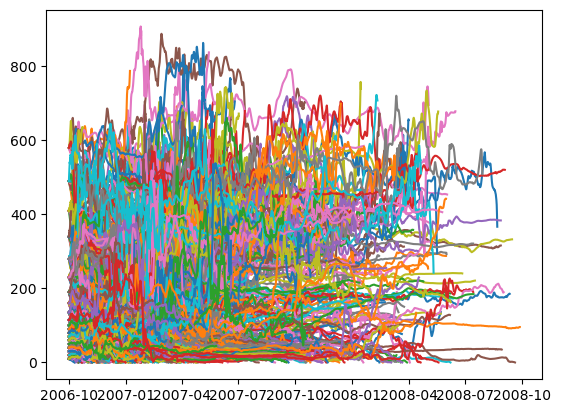

In [12]:
# Did the code break early(all beached at similar time) or are they actually beached
for drifter in beached_ids_aw:
    plt.plot(ds.time, ds.sel(drifter=drifter).depth)

In [ ]:
def basic_gate_map(ax, labels = True):

    gates       = [P1, P2, P3, P4, P5]
    gate_colors = ["grey", "blue", "red", "green", "mediumturquoise"]
    gate_names  = ["P1", "P2", "P3", "P4", "P5"]
    # Bathymetry
    ax.contour(
        ds_bath.lon.values[::4], ds_bath.lat.values[::4], ds_bath.z.values[::4, ::4] * -1,
        levels=np.arange(1000, 5001, 1000), cmap="Greys", #np.arange(0, 6001, 1000)
        transform=ccrs.PlateCarree(), zorder=2)
    
    for line, color, name in zip(gates, gate_colors, gate_names):
        # Plotting
        x, y = line.xy
        ax.plot(x, y, color=color, linewidth=2, label='Boundary Line',
            transform=ccrs.PlateCarree(), zorder=12)
        ax.scatter(x, y, color='black', zorder=13,
            transform=ccrs.PlateCarree()) # Endpoints
        mid = len(x) // 2
        
        if labels:
            ax.text(x[mid], y[mid] + 0.1, name, color=color,
                transform=ccrs.PlateCarree(), fontsize=12, fontweight="bold", zorder=14,
                ha='left', va='bottom',
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.6))  # white background for readability

    gl = ax.gridlines(draw_labels=True)
    ax.add_feature(cartopy.feature.LAND, color="grey", zorder=10)

        # Force a draw so Cartopy generates the label artists
    ax.figure.canvas.draw()

    # The actual label artists live in gl.label_artists (Cartopy >= 0.20)
    for artist in gl.label_artists:
        artist.set_zorder(20)
    

    return ax

def tracks_on_map(ax, drifters, T=24):
    for d_id in drifters:

        d_data = ds.sel(drifter=d_id)
    
        lon_vals = d_data.lon.values[::T]
        lat_vals = d_data.lat.values[::T]
        
        mask = np.isfinite(lon_vals) & np.isfinite(lat_vals)
        
        # Only plot if we still have points after filtering NaNs
        if np.any(mask):
            ax.plot(lon_vals[mask], lat_vals[mask], 
                    transform=ccrs.PlateCarree(), 
                    label=str(d_id),
                    alpha=0.5, linewidth=1) # Suggested for many lines
    return ax

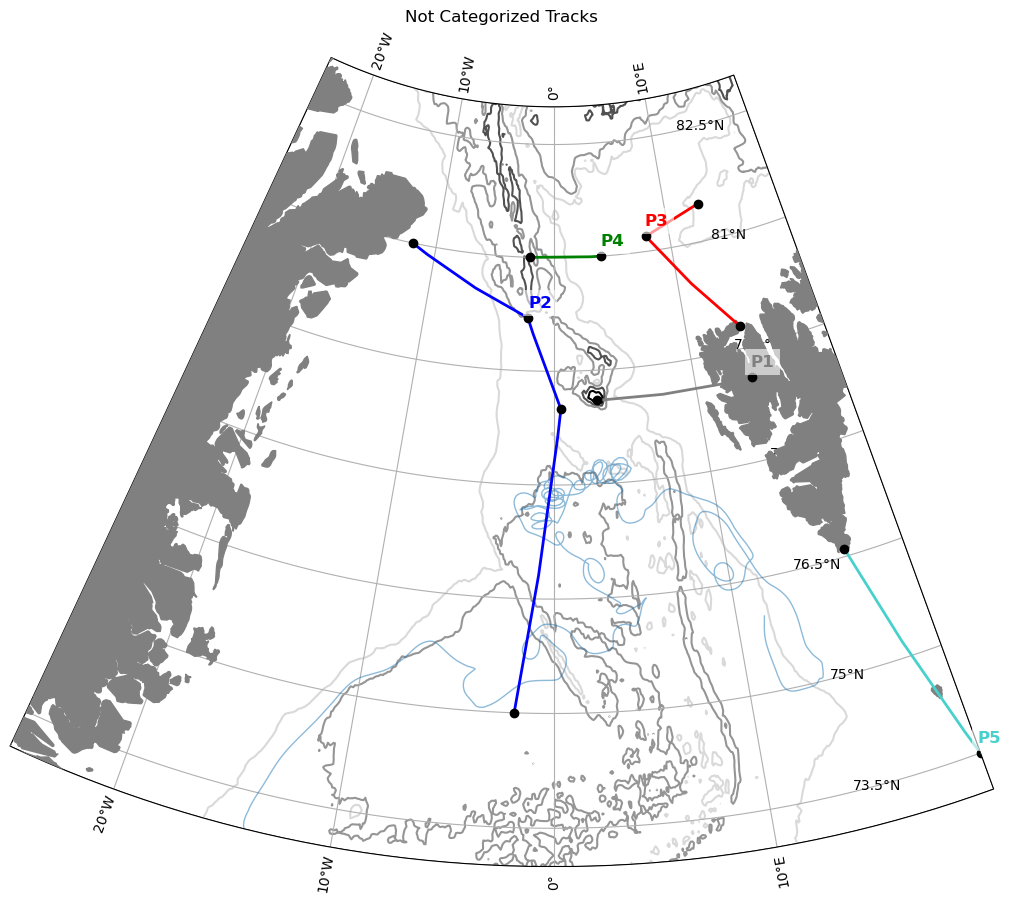

In [15]:
fig, ax = plf.plot_empty_map_wedge(land_color=None, figsize=(10, 10), extent=[-25, 20, 73, 83])
ax = basic_gate_map(ax)

ax = tracks_on_map(ax, [1116], T=6) #[200, 400, 600, 800]
ax.set_title("Not Categorized Tracks")
fig.show()

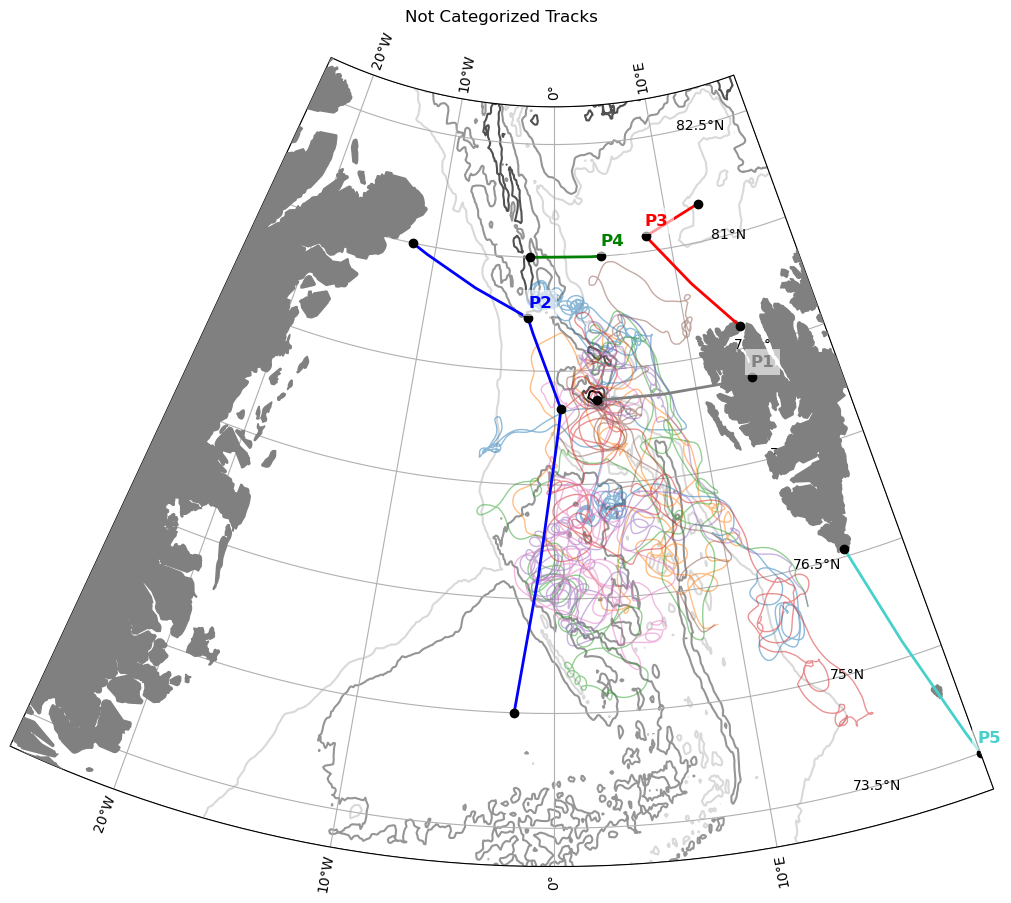

In [18]:
if all(g is not None for g in (summary.all_crossers, summary.north, summary.south, summary.yermak, summary.arctic, summary.svalbard)):
            categorized = set().union(*[g.data for g in summary.tracks if g is not None])
            uncategorized = summary.all_crossers.data - categorized

fig, ax = plf.plot_empty_map_wedge(land_color=None, figsize=(10, 10), extent=[-25, 20, 73, 83])
ax = basic_gate_map(ax)

ax = tracks_on_map(ax, uncategorized, T=6) #[200, 400, 600, 800]
ax.set_title("Not Categorized Tracks")
fig.show()

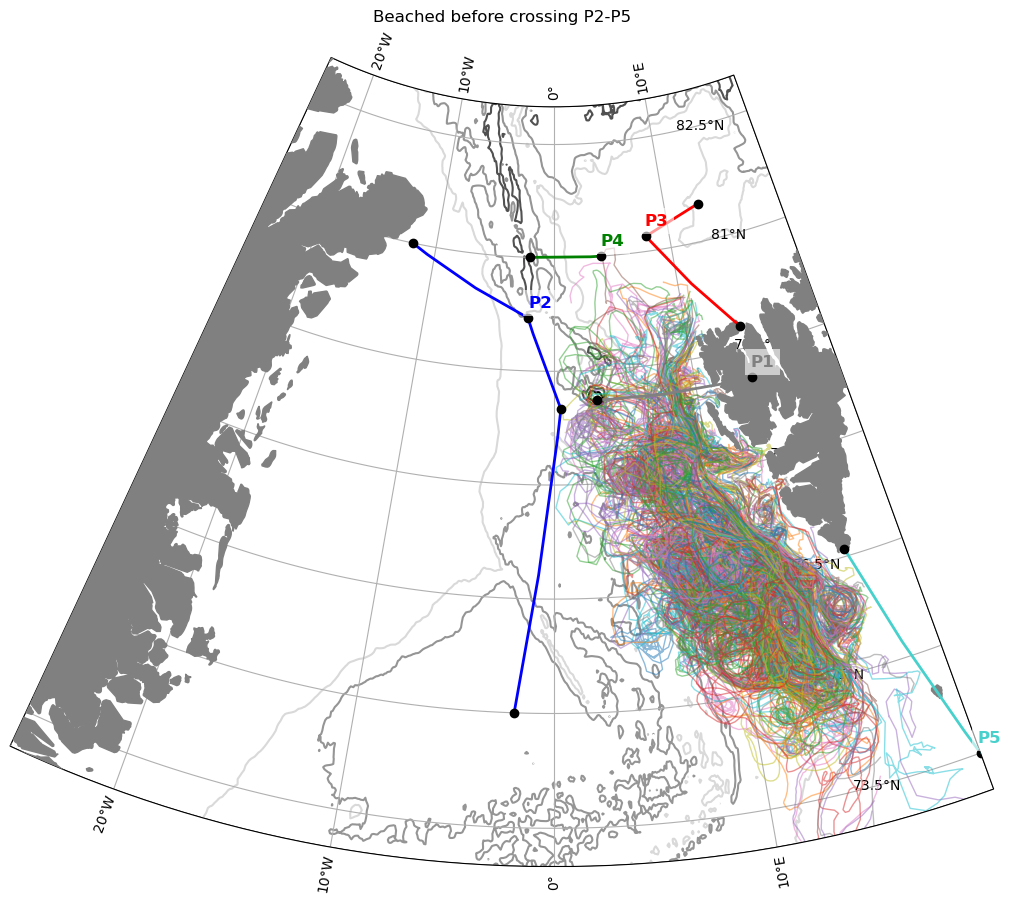

In [17]:
fig, ax = plf.plot_empty_map_wedge(land_color=None, figsize=(10, 10), extent=[-25, 20, 73, 83])
ax = basic_gate_map(ax)

ax = tracks_on_map(ax, beached_ids_aw - all_crossers, T=6*4) #[200, 400, 600, 800]
ax.set_title("Beached before crossing P2-P5")
fig.show()

Extracting positions for 472 drifters...


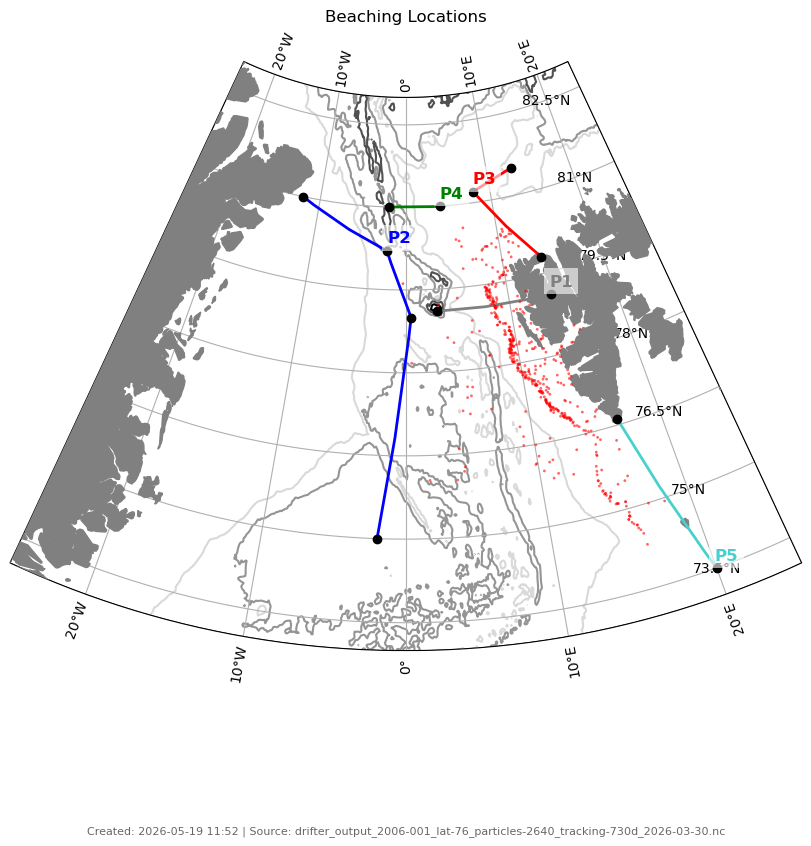

In [75]:
fig, ax = plf.plot_empty_map_wedge(land_color=None, figsize=(8, 8), extent=[-25, 25, 73, 83])
ax = basic_gate_map(ax)

test_ids = [202, 402, 602, 802]

last_lons = []
last_lats = []
last_depth = []

print(f"Extracting positions for {len(beached_ids_aw - all_crossers)} drifters...")

for d_id in beached_ids_aw - all_crossers:
    # Optimization: drop NaNs and take the last point
    d_data = ds.sel(drifter=d_id).dropna(dim='time')
    if len(d_data.time) > 0:
        last_lons.append(d_data.lon.values[-1])
        last_lats.append(d_data.lat.values[-1])
        last_depth.append(d_data.depth.values[-1])

# 3. Plot as Scatter
# We use a small 's' and some transparency (alpha) to see density
sc = ax.scatter(
    last_lons, last_lats, 
    color="red", s=4, alpha=0.6, edgecolors='none',
    transform=ccrs.PlateCarree(), zorder=20,
    label=f'Beaching Locations (n={len(last_lons)})'
)

ax.set_title("Beaching Locations")
hlp.add_plot_footer(fig=fig, data=filename)
fig.show()

## Preliminary Analysis

In [ ]:
tracks = [r_north, r_south, r_yermak, r_arctic, r_svalbard]

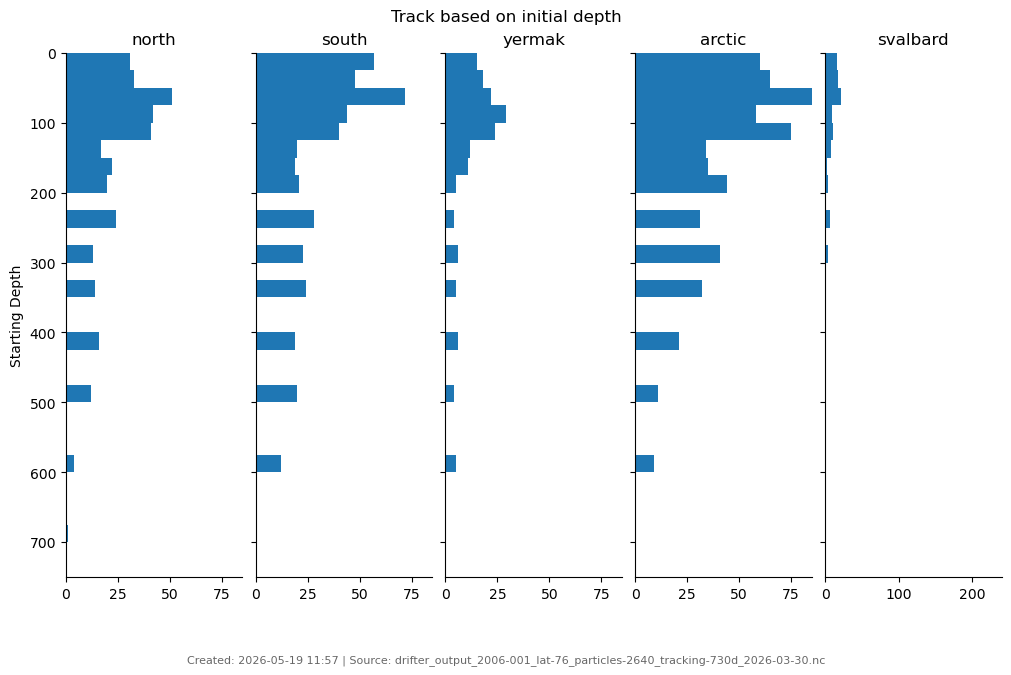

In [ ]:
bins = np.arange(0, 750, 25)


fig, axes = plt.subplots(1, len(tracks), constrained_layout=True, sharey=True, figsize=(10,6))

for ax, track in zip(axes, tracks):
    ax.hist(ds.sel(drifter=list(track.data)).depth.isel(time=0).values, orientation='horizontal', label=track.name, bins=bins) #, density=True
    short_name = "\n".join(track.name.split(" ")[:2]) 
    ax.set_title(short_name)
    ax.set_ylim(750,0)
    ax.set_xlim(0,85)

axes[0].set_ylabel("Starting Depth")
axes[-1].set_xlim(0,240)
hlp.add_plot_footer(fig=fig, data=filename)
hlp.despine(axes)
fig.suptitle("Track based on initial depth") # Note that the particles are not released uniform in depth but at the FESOM model levels
plt.show()


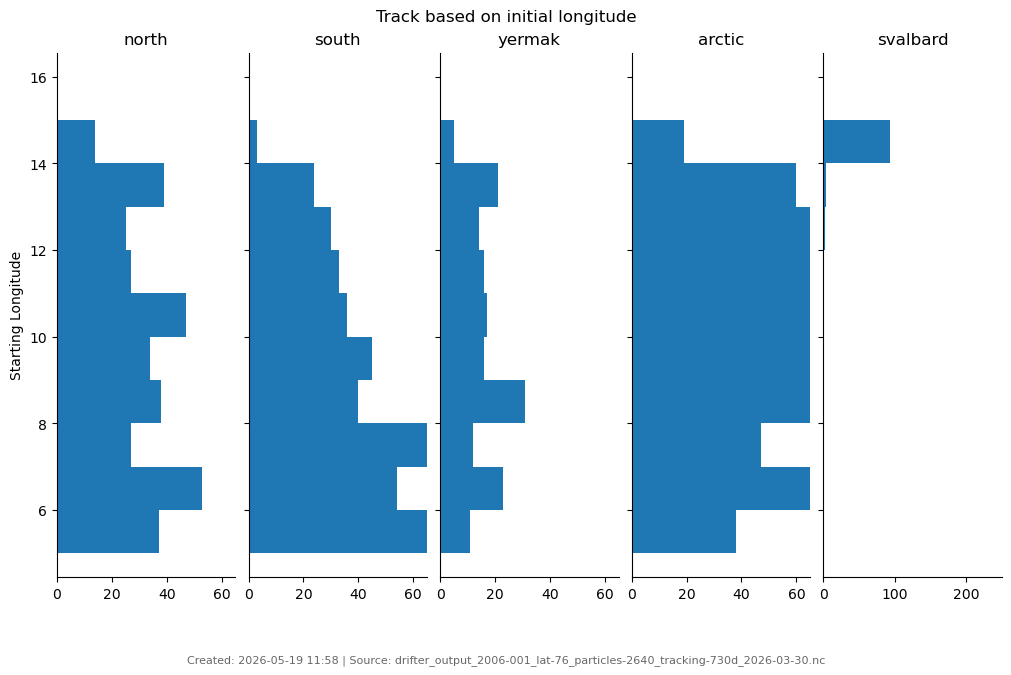

In [86]:
bins = np.arange(5, 17, 1)

fig, axes = plt.subplots(1, len(tracks), constrained_layout=True, sharey=True, figsize=(10,6))

for ax, track in zip(axes, tracks):
    ax.hist(ds.sel(drifter=list(track.data)).lon.isel(time=0).values, orientation='horizontal', label=track.name, bins=bins) #, density=True
    short_name = "\n".join(track.name.split(" ")[:2]) 
    ax.set_title(short_name)
    ax.set_xlim(0,65)

axes[0].set_ylabel("Starting Longitude")
axes[-1].set_xlim(0, 250)
hlp.despine(axes)
hlp.add_plot_footer(fig=fig, data=filename)
fig.suptitle("Track based on initial longitude")

plt.show()

Calculated Master Gridsize: 56


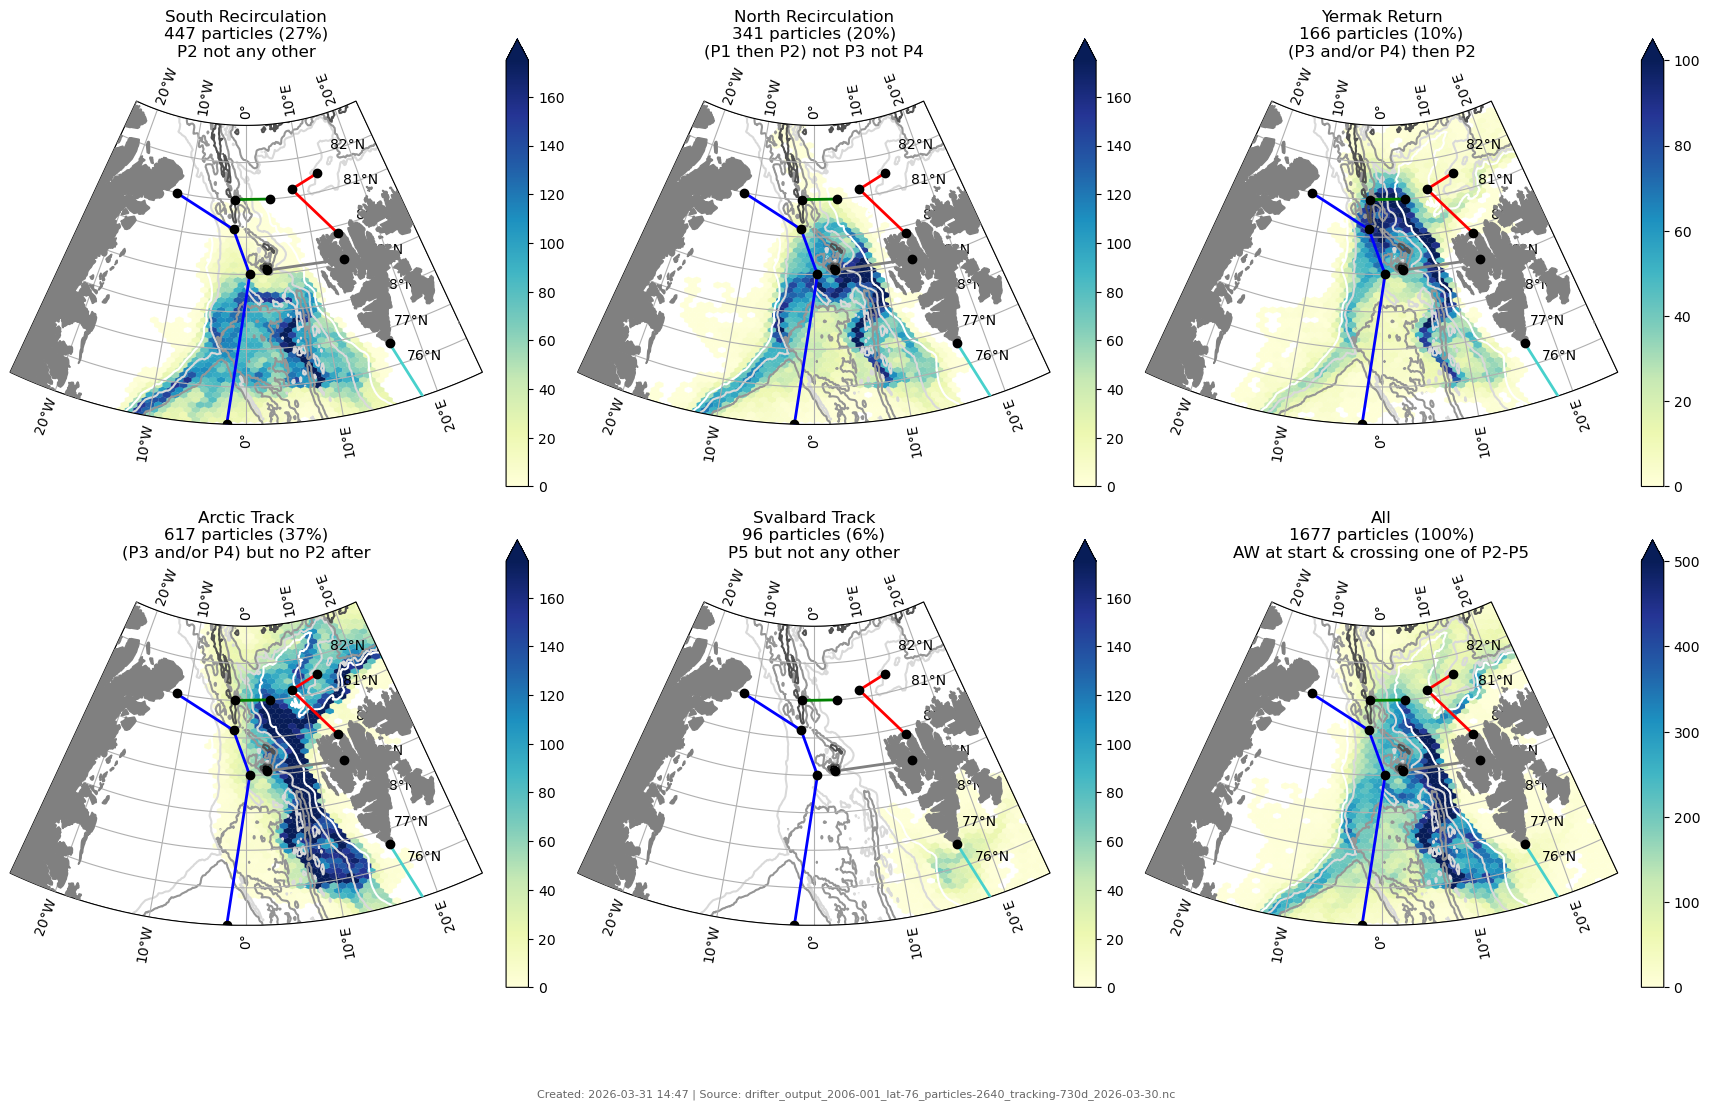

In [ ]:
import numpy as np
import cartopy.crs as ccrs

# 1. Define the map limits (in degrees)
lon_lims = [-25, 25]
lat_lims = [75, 83]

# 2. Create a dense boundary of the map to find the true min/max in meters
# This samples points along all four edges of your wedge
lons_edge = np.concatenate([
    np.linspace(lon_lims[0], lon_lims[1], 50), # Bottom edge
    np.full(50, lon_lims[1]),                  # Right edge
    np.linspace(lon_lims[1], lon_lims[0], 50), # Top edge
    np.full(50, lon_lims[0])                   # Left edge
])
lats_edge = np.concatenate([
    np.full(50, lat_lims[0]),                  # Bottom edge
    np.linspace(lat_lims[0], lat_lims[1], 50), # Right edge
    np.full(50, lat_lims[1]),                  # Top edge
    np.linspace(lat_lims[1], lat_lims[0], 50)  # Left edge
])

equal_area_crs = ccrs.LambertAzimuthalEqualArea(central_latitude=90, central_longitude=0)
# Project this boundary to find the true physical limits
boundary_projected = equal_area_crs.transform_points(ccrs.PlateCarree(), lons_edge, lats_edge)
X_MIN, X_MAX = boundary_projected[:, 0].min(), boundary_projected[:, 0].max()
Y_MIN, Y_MAX = boundary_projected[:, 1].min(), boundary_projected[:, 1].max()

# 3. Calculate Global Gridsize for EXACTLY 25km
# Gridsize is the number of hexagons across the X-range
X_RANGE_M = X_MAX - X_MIN
GLOBAL_GRIDSIZE = int(X_RANGE_M / 25000)
GLOBAL_EXTENT = [X_MIN, X_MAX, Y_MIN, Y_MAX]

print(f"Calculated Master Gridsize: {GLOBAL_GRIDSIZE}")

def plot_true_equal_area_heatmap(drifter_ids, ds, ax, vmax=None):
    lons, lats, ids = [], [], []
    for d_id in drifter_ids:
        d_data = ds.sel(drifter=d_id)
        mask = np.isfinite(d_data.lon.values) & np.isfinite(d_data.lat.values)
        lons.extend(d_data.lon.values[mask])
        lats.extend(d_data.lat.values[mask])
        ids.extend([d_id] * np.sum(mask))

    # Project the drifter points to meters
    projected_points = equal_area_crs.transform_points(
        ccrs.PlateCarree(), np.array(lons), np.array(lats)
    )
    x, y = projected_points[:, 0], projected_points[:, 1]

    # Plot Hexbin
    hb = ax.hexbin(
        x, y, 
        C=np.array(ids), 
        reduce_C_function=lambda val: len(set(val)),
        gridsize=GLOBAL_GRIDSIZE, 
        extent=GLOBAL_EXTENT,  # This aligns the grid across all plots
        cmap='YlGnBu', 
        mincnt=1, 
        transform=equal_area_crs, 
        zorder=0,
        linewidths=0.2,
        vmin=0,
        vmax=vmax
        #edgecolor="black",
    )
    return hb

# --- Inside your loop ---
# Use the same UNIVERSAL_GRIDSIZE for every call

fig = plt.figure(figsize=(17, 10), constrained_layout=True)
fig, ax1 = plf.plot_empty_map_wedge(extent=[-25, 25, 75, 83], land_color=None, land_zorder=50, fig=fig, ax=None, position=231, figsize=(15, 4), projection=ccrs.NorthPolarStereo())
fig, ax2 = plf.plot_empty_map_wedge(extent=[-25, 25, 75, 83], land_color=None, land_zorder=50, fig=fig, ax=None, position=232, figsize=(15, 4), projection=ccrs.NorthPolarStereo())
fig, ax3 = plf.plot_empty_map_wedge(extent=[-25, 25, 75, 83], land_color=None, land_zorder=50, fig=fig, ax=None, position=233, figsize=(15, 4), projection=ccrs.NorthPolarStereo())
fig, ax4 = plf.plot_empty_map_wedge(extent=[-25, 25, 75, 83], land_color=None, land_zorder=50, fig=fig, ax=None, position=234, figsize=(15, 4), projection=ccrs.NorthPolarStereo())
fig, ax5 = plf.plot_empty_map_wedge(extent=[-25, 25, 75, 83], land_color=None, land_zorder=50, fig=fig, ax=None, position=235, figsize=(15, 4), projection=ccrs.NorthPolarStereo())
fig, ax6 = plf.plot_empty_map_wedge(extent=[-25, 25, 75, 83], land_color=None, land_zorder=50, fig=fig, ax=None, position=236, figsize=(15, 4), projection=ccrs.NorthPolarStereo())


axs = [ax1, ax2, ax3, ax4, ax5, ax6]
vmaxes = [175, 175, 100, 175, 175, 500]

for ax, vmax, track in zip(axs, vmaxes, tracks):
    hb = plot_true_equal_area_heatmap(track.data, ds, ax=ax, vmax=vmax)
    fig.colorbar(hb, ax=ax, extend="max")
    _ = basic_gate_map(ax, labels=False)
    
    ax.set_title(f"{track.name}\n{len(track.data)} particles ({len(track.data)/len(all_crossers)*100:.0f}%)\n{track.desc}")

hlp.add_plot_footer(fig=fig, data=filename)


In [44]:
len(all_crossers)

1705